# Analyse des données — A, B, Y

## Imports

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import math

from scipy import stats
from scipy.optimize import linear_sum_assignment
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import PassiveAggressiveRegressor, RANSACRegressor, HuberRegressor
from sklearn.metrics import r2_score, silhouette_score, mean_absolute_error, mean_squared_error, accuracy_score, classification_report, confusion_matrix
from lazypredict.Supervised import LazyRegressor

import joblib

## Observer les données

Je regarde comment sont les données dans le tableau

In [85]:
df = pd.read_csv('data.csv')
df.head(10)

,A,B,Y
0,1.29,13,15
1,5.84,24,33
2,2.35,31,35
3,0.48,10,11
4,1.53,20,23
5,4.97,20,28
6,0.32,20,21
7,2.11,17,21
8,5.15,22,30
9,1.91,12,15


In [86]:
df.dtypes

A    float64
B      int64
Y      int64
dtype: object

On peut essayer d'afficher les données et de faire des tests dessus

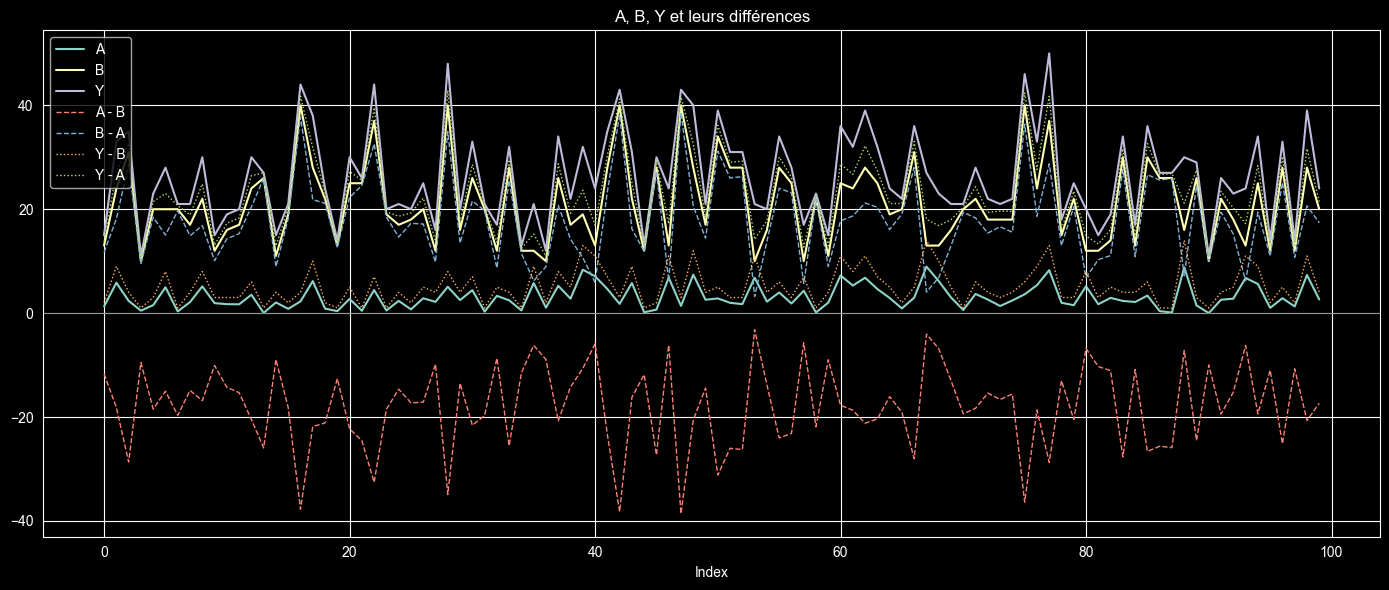

In [87]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['A'], label='A', linewidth=1.5)
ax.plot(df.index, df['B'], label='B', linewidth=1.5)
ax.plot(df.index, df['Y'], label='Y', linewidth=1.5)
ax.plot(df.index, df['A']-df['B'], label='A - B', linewidth=1, linestyle='--')
ax.plot(df.index, df['B']-df['A'], label='B - A', linewidth=1, linestyle='--')
ax.plot(df.index, df['Y']-df['B'], label='Y - B', linewidth=1, linestyle=':')
ax.plot(df.index, df['Y']-df['A'], label='Y - A', linewidth=1, linestyle=':')

ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.set_xlabel('Index')
ax.set_title('A, B, Y et leurs différences')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Analyser les données (corrélations)

Je vais regarder s'il y a des corrélations entre mes datas

In [88]:
corr = df.corr()
print('Matrice de corrélation :')
corr.round(4)

Matrice de corrélation :


,A,B,Y
A,1.00,0.11,0.48
B,0.11,1.00,0.92
Y,0.48,0.92,1.00


## Questions de prédiction

### Peut-on prédire B en fonction de A ?

In [89]:
r, p_value = stats.pearsonr(df['A'], df['B'])
print(f'Corrélation de Pearson : {r:.4f}')

Corrélation de Pearson : 0.1051


La corrélation est trop petite pour qu'on puisse prédire B en fonction de A

### Peut-on prédire Y en fonction de A ?

In [90]:
r, p_value = stats.pearsonr(df['A'], df['Y'])
print(f'Corrélation de Pearson : {r:.4f}')

Corrélation de Pearson : 0.4769


La corrélation est minime mais il peut potentiellement y en avoir une

### Peut-on prédire Y en fonction de B ?

In [91]:
r, p_value = stats.pearsonr(df['B'], df['Y'])
print(f'Corrélation de Pearson : {r:.4f}')

Corrélation de Pearson : 0.9236


Ici, la corrélation est très grande on peut donc prédire Y en fonction de B

### Peut-on prédire Y en fonction de A et B ?

In [92]:
X_AB = sm.add_constant(df[['A', 'B']])
model = sm.OLS(df['Y'], X_AB).fit()
print(f'Précision : {model.rsquared:.4f}')

Précision : 0.9989


On peut encore mieux prédire ici

## Comparaison des modèles

On cherche le meilleur modèle pour Y en fonction de A

In [93]:
X = df[['A']]
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)
models

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000027 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 1
[LightGBM] [Info] Start training from score 26.262500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
PassiveAggressiveRegressor,0.36,0.39,7.57,0.02
LarsCV,0.32,0.36,7.75,0.01
OrthogonalMatchingPursuit,0.32,0.36,7.75,0.01
TransformedTargetRegressor,0.32,0.36,7.75,0.02
LassoLarsCV,0.32,0.36,7.75,0.02
LassoLarsIC,0.32,0.36,7.75,0.01
LinearRegression,0.32,0.36,7.75,0.01
Lars,0.32,0.36,7.75,0.01
LassoCV,0.32,0.36,7.75,0.08


In [94]:
best_name = models.index[0]
print(f'Meilleur modèle : {best_name}')
print(f'Précision : {models.iloc[0]["R-Squared"]:.4f}')
print(f'Marge d erreur : {models.iloc[0]["RMSE"]:.4f}')

Meilleur modèle : PassiveAggressiveRegressor
Précision : 0.3895
Marge d erreur : 7.5686


On cherche le meilleur modèle pour Y en fonction de B

In [95]:
X = df[['B']]
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)
models

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000015 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 1
[LightGBM] [Info] Start training from score 26.262500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
RANSACRegressor,0.84,0.85,3.78,0.02
PoissonRegressor,0.84,0.84,3.81,0.02
HuberRegressor,0.84,0.84,3.83,0.03
LarsCV,0.83,0.84,3.85,0.02
LassoLarsIC,0.83,0.84,3.85,0.01
Lars,0.83,0.84,3.85,0.01
LassoLarsCV,0.83,0.84,3.85,0.02
OrthogonalMatchingPursuit,0.83,0.84,3.85,0.02
TransformedTargetRegressor,0.83,0.84,3.85,0.02


In [96]:
best_name = models.index[0]
print(f'Meilleur modèle : {best_name}')
print(f'Précision : {models.iloc[0]["R-Squared"]:.4f}')
print(f'Marge d erreur : {models.iloc[0]["RMSE"]:.4f}')

Meilleur modèle : RANSACRegressor
Précision : 0.8476
Marge d erreur : 3.7808


On cherche le meilleur modèle pour prédire Y en fonction de A et B

In [97]:
X = df[['A', 'B']]
y = df['Y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)
models

  0%|          | 0/42 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000020 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 44
[LightGBM] [Info] Number of data points in the train set: 80, number of used features: 2
[LightGBM] [Info] Start training from score 26.262500
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
HuberRegressor,1.00,1.00,0.29,0.05
LassoCV,1.00,1.00,0.29,0.17
RidgeCV,1.00,1.00,0.29,0.01
BayesianRidge,1.00,1.00,0.29,0.02
LarsCV,1.00,1.00,0.29,0.02
LassoLarsIC,1.00,1.00,0.29,0.02
Lars,1.00,1.00,0.29,0.02
LassoLarsCV,1.00,1.00,0.29,0.02
LinearRegression,1.00,1.00,0.29,0.01


In [98]:
best_name = models.index[0]
print(f'Meilleur modèle : {best_name}')
print(f'Précision : {models.iloc[0]["R-Squared"]:.4f}')
print(f'Marge d erreur : {models.iloc[0]["RMSE"]:.4f}')

Meilleur modèle : HuberRegressor
Précision : 0.9991
Marge d erreur : 0.2878


- Pour Y en fonction de A on utilisera => PassiveAggressiveRegressor
- Pour Y en fonction de B on utilisera => RANSACRegressor
- Pour Y en fonction de A et B on utilisera => HuberRegressor

## Entraînement des modèles de régression

In [99]:
# Train de Y en fonction de A
X_train, X_test, y_train, y_test = train_test_split(df[['A']], df['Y'], test_size=0.2, random_state=42)
model_A = PassiveAggressiveRegressor(random_state=42)
model_A.fit(X_train, y_train)
print(f'PassiveAggressiveRegressor (A → Y) : Précision={r2_score(y_test, model_A.predict(X_test)):.4f}')
joblib.dump(model_A, 'models/model_A.pkl')

# Train de Y en fonction de B
X_train, X_test, y_train, y_test = train_test_split(df[['B']], df['Y'], test_size=0.2, random_state=42)
model_B = RANSACRegressor(random_state=42)
model_B.fit(X_train, y_train)
print(f'RANSACRegressor (B → Y) : Précision={r2_score(y_test, model_B.predict(X_test)):.4f}')
joblib.dump(model_B, 'models/model_B.pkl')

# Train de Y en fonction de A et B
X_train, X_test, y_train, y_test = train_test_split(df[['A', 'B']], df['Y'], test_size=0.2, random_state=42)
model_AB = HuberRegressor()
model_AB.fit(X_train, y_train)
print(f'HuberRegressor (A+B → Y) : Précision={r2_score(y_test, model_AB.predict(X_test)):.4f}')
joblib.dump(model_AB, 'models/model_AB.pkl')

PassiveAggressiveRegressor (A → Y) : Précision=0.2391
RANSACRegressor (B → Y) : Précision=0.8476
HuberRegressor (A+B → Y) : Précision=0.9991


['models/model_AB.pkl']

## Clustering sur data.csv (A, B, Y)

On entraîne un KMeans sur A et B

In [100]:
scaler_ab = StandardScaler()
X_scaled_ab = scaler_ab.fit_transform(df[['A', 'B']])
kmeans_ab = KMeans(n_clusters=3, random_state=42, n_init=10)
df['classe_ab'] = kmeans_ab.fit_predict(X_scaled_ab) + 1
joblib.dump({'kmeans': kmeans_ab, 'scaler': scaler_ab}, 'models/clustering_ab.pkl')
print('clustering_ab.pkl sauvegardé')
print(df['classe_ab'].value_counts().sort_index())

clustering_ab.pkl sauvegardé
classe_ab
1    25
2    48
3    27
Name: count, dtype: int64


On entraîne un KMeans sur A, B et Y

In [101]:
scaler_aby = StandardScaler()
X_scaled_aby = scaler_aby.fit_transform(df[['A', 'B', 'Y']])
kmeans_aby = KMeans(n_clusters=3, random_state=42, n_init=10)
df['classe_aby'] = kmeans_aby.fit_predict(X_scaled_aby) + 1
joblib.dump({'kmeans': kmeans_aby, 'scaler': scaler_aby}, 'models/clustering_aby.pkl')
print('clustering_aby.pkl sauvegardé')
print(df['classe_aby'].value_counts().sort_index())

clustering_aby.pkl sauvegardé
classe_aby
1    14
2    35
3    51
Name: count, dtype: int64


Visualisation des clusters

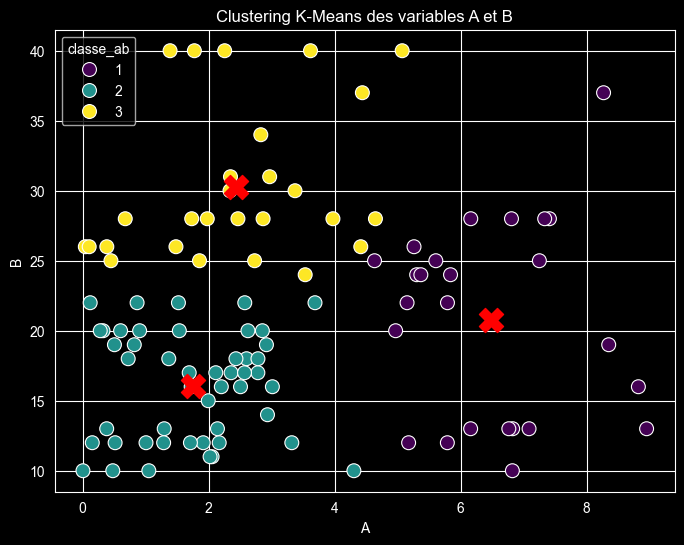

In [102]:
centres = scaler_ab.inverse_transform(kmeans_ab.cluster_centers_)

plt.style.use('dark_background')
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='A', y='B', hue='classe_ab', palette='viridis', s=100)
plt.scatter(centres[:,0], centres[:,1], c='red', marker='X', s=300)
plt.title('Clustering K-Means des variables A et B')
plt.show()

Score de silhouette — qualité des clusters

In [103]:
score = silhouette_score(X_scaled_ab, df['classe_ab'])
print(f'Silhouette score : {score:.4f}')

Silhouette score : 0.4463


Ce n'est pas un super résultat, on peut dire que c'est moyen. On peut en conclure, comme vu sur le graphique, qu'on n'a pas 3 groupes hyper distincts.

Profiling des clusters

In [104]:
df.groupby('classe_ab')[['A', 'B', 'Y']].agg(['mean', 'min', 'max'])

A               B             Y        
          mean  min  max  mean min max  mean min max
classe_ab                                           
1         6.48 4.63 8.95 20.80  10  37 31.00  20  50
2         1.74 0.00 4.30 16.08  10  22 19.21  11  28
3         2.43 0.04 5.07 30.30  24  40 34.48  26  48

L'analyse des clusters montre trois profils distincts :
- Classe 1 : A élevé, Y intermédiaire
- Classe 2 : A et B faibles, Y faible
- Classe 3 : B élevé, Y fort

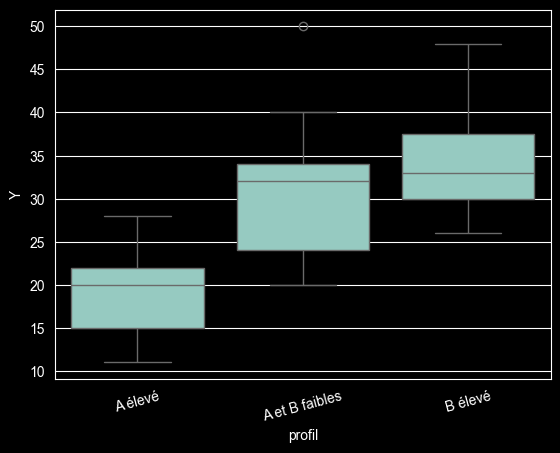

In [105]:
df['profil'] = df['classe_ab'].map({
    1: 'A et B faibles',
    2: 'A élevé',
    3: 'B élevé'
})

sns.boxplot(data=df, x='profil', y='Y')
plt.xticks(rotation=15)
plt.show()

## Prédiction sur data_test.csv via l'API

On charge data_test.csv, on prédit Y puis la classe (A, B, Y_pred) via l'API

In [106]:
import requests

df_test = pd.read_csv('data_test.csv')
results = []

for _, row in df_test.iterrows():
    res_predict = requests.post(
        'http://127.0.0.1:8000/predict',
        json={'A': row['A'], 'B': int(row['B'])}
    )
    y_pred = res_predict.json()['Y_pred']

    res_classe = requests.post(
        'http://127.0.0.1:8000/classe_aby',
        json={'A': row['A'], 'B': int(row['B']), 'Y': y_pred}
    )
    classe = res_classe.json()['classe'] + 1

    results.append({
        'A':         row['A'],
        'B':         row['B'],
        'Y_pred':    y_pred,
        'classe_aby': classe,
    })

df_results = pd.DataFrame(results)
df_results.to_csv('resultats_test.csv', index=False)
df_results.head()

,A,B,Y_pred,classe_aby
0,2.05,11.00,14.58,3
1,2.83,20.00,24.76,3
2,0.50,19.00,20.28,3
3,1.61,19.00,21.92,3
4,3.53,24.00,29.80,2


## Comparaison avec data_test_ok.csv

In [107]:
df_pred = pd.read_csv('resultats_test.csv')
df_ok   = pd.read_csv('data_test_ok.csv')

y_pred_arrondi = df_pred['Y_pred'].round().astype(int)

df_compare = pd.DataFrame({
    'A':             df_pred['A'],
    'B':             df_pred['B'],
    'Y_pred':        y_pred_arrondi,
    'Y_reel':        df_ok['Y'],
    'erreur_Y':      (y_pred_arrondi - df_ok['Y']).abs().round(4),
    'classe_pred':   df_pred['classe_aby'],
    'classe_reelle': df_ok['classe'],
    'classe_ok':     df_pred['classe_aby'] == df_ok['classe']
})

df_compare.to_csv('comparaison.csv', index=False)
print(f'Lignes avec mauvaise classe : {(~df_compare["classe_ok"]).sum()}/{len(df_compare)}')

Lignes avec mauvaise classe : 85/100


Visualisation des erreurs de classification

[3 2 1]
[1 3 2]


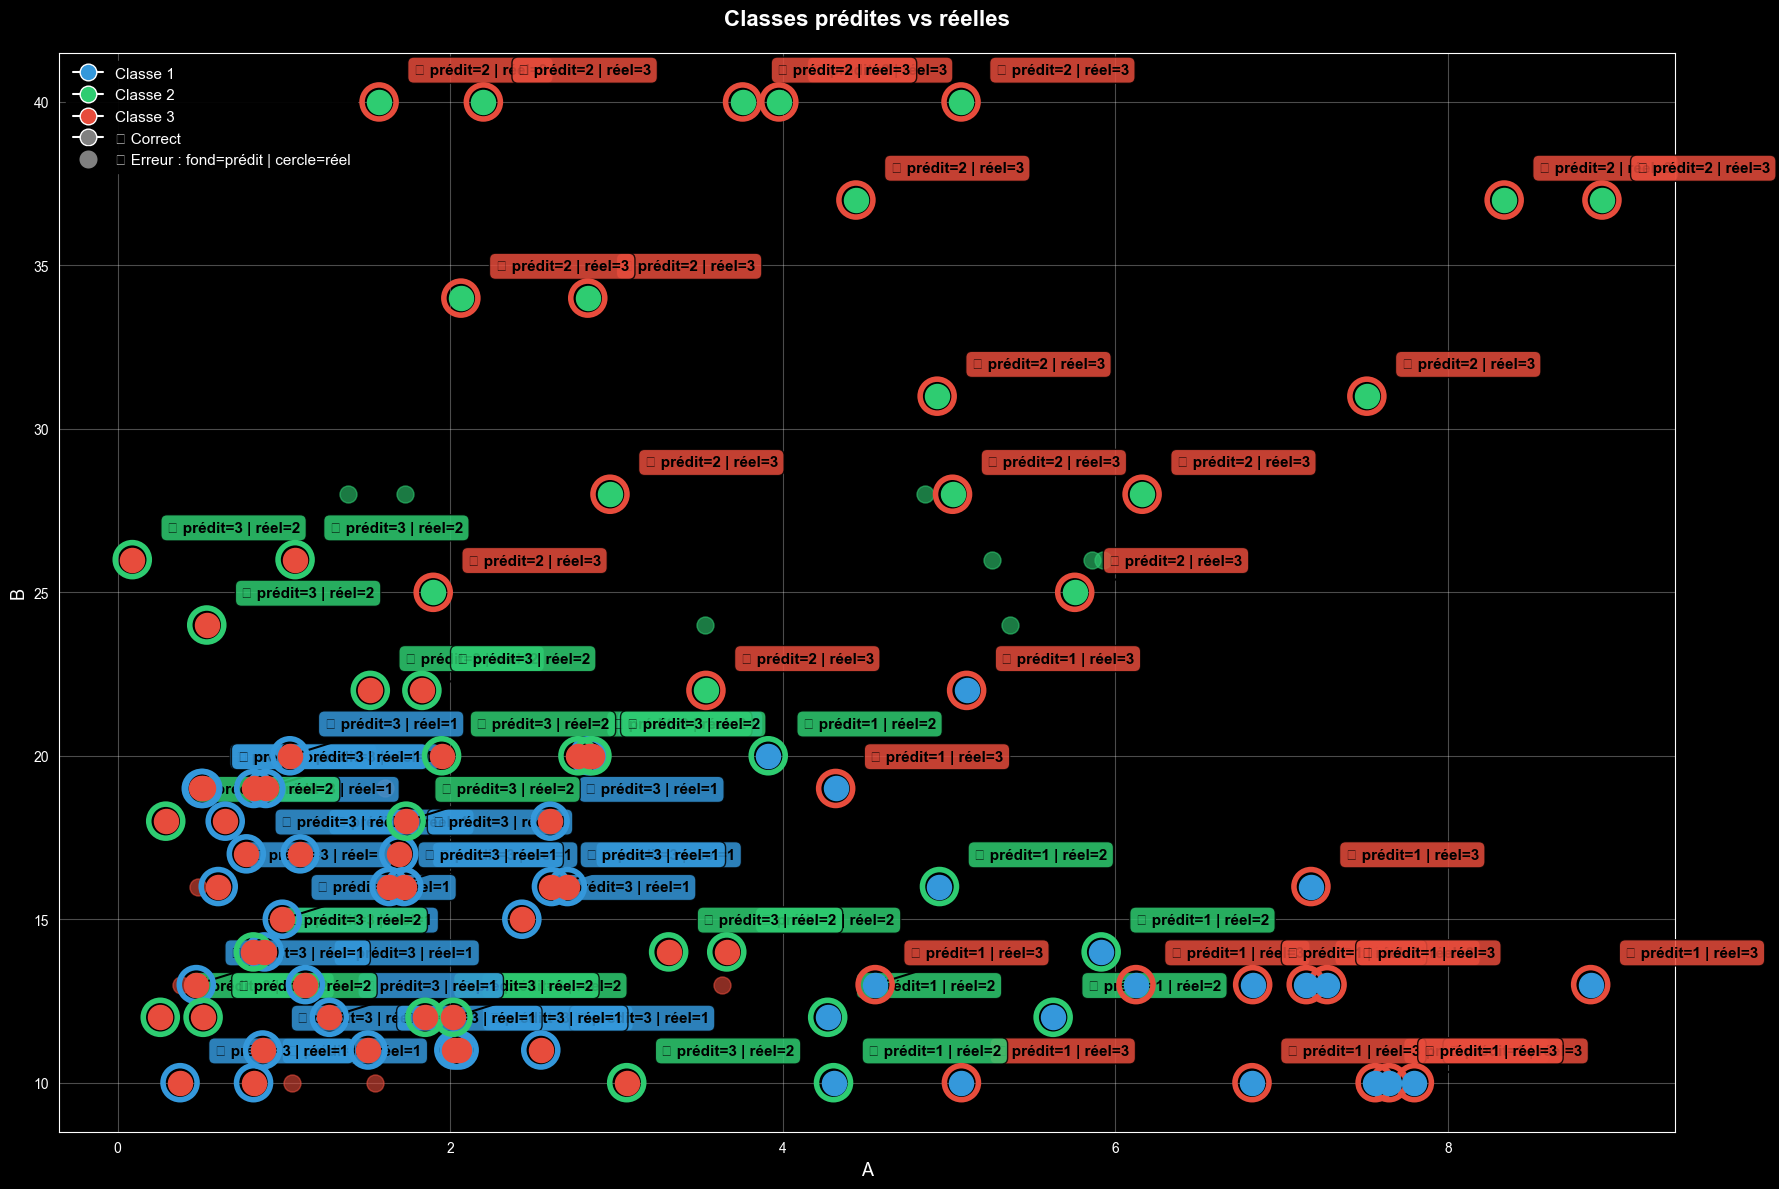

In [108]:
print(df_compare['classe_pred'].unique())
print(df_compare['classe_reelle'].unique())

fig, ax = plt.subplots(figsize=(18, 12))
ax.set_title('Classes prédites vs réelles', fontsize=16, fontweight='bold', pad=20)

colors = {1: '#3498db', 2: '#2ecc71', 3: '#e74c3c'}
erreurs  = df_compare[~df_compare['classe_ok']]
corrects = df_compare[df_compare['classe_ok']]

for c, grp in corrects.groupby('classe_pred'):
    ax.scatter(grp['A'], grp['B'], color=colors[c], s=150, alpha=0.6, zorder=3)

for _, row in erreurs.iterrows():
    cp = int(row['classe_pred'])
    cr = int(row['classe_reelle'])
    ax.scatter(row['A'], row['B'], color=colors[cp], s=300, zorder=5)
    ax.scatter(row['A'], row['B'], facecolors='none', edgecolors=colors[cr], linewidths=4, s=600, zorder=4)
    ax.annotate(
        f'✗ prédit={cp} | réel={cr}',
        xy=(row['A'], row['B']),
        xytext=(25, 20), textcoords='offset points',
        fontsize=11, fontweight='bold', color='black',
        arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.4', fc=colors[cr], ec='black', alpha=0.85)
    )

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[1], markersize=12, label='Classe 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[2], markersize=12, label='Classe 2'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=colors[3], markersize=12, label='Classe 3'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=12, label='✓ Correct'),
    Line2D([0], [0], marker='o', color='black', markerfacecolor='gray', markersize=16, markeredgewidth=3, label='✗ Erreur : fond=prédit | cercle=réel'),
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.95, edgecolor='black')
ax.set_xlabel('A', fontsize=13)
ax.set_ylabel('B', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

On voit qu'il y a des erreurs de classification, mais cela ne signifie pas que nos clusters sont faux.
Les deux modèles de clustering ont été entraînés sur des datasets différents : ils ont trouvé des groupes cohérents mais les ont numérotés différemment.

## Ré-entraînement d'un clustering sur data_test (A, B, Y_pred)

On prédit Y sur data_test avec model_AB, puis on entraîne un nouveau KMeans sur A, B, Y_pred

In [109]:
df_test = pd.read_csv('data_test.csv')
df_test['Y_pred'] = model_AB.predict(df_test[['A', 'B']])

scaler_test = StandardScaler()
X_scaled_test = scaler_test.fit_transform(df_test[['A', 'B', 'Y_pred']])
kmeans_test = KMeans(n_clusters=3, random_state=42, n_init=10)
df_test['classe_pred'] = kmeans_test.fit_predict(X_scaled_test) + 1

joblib.dump({'kmeans': kmeans_test, 'scaler': scaler_test}, 'models/clustering_test.pkl')
print('clustering_test.pkl sauvegardé')
print(df_test['classe_pred'].value_counts().sort_index())

clustering_test.pkl sauvegardé
classe_pred
1    20
2    56
3    24
Name: count, dtype: int64


On compare ces nouvelles classes avec celles de data_test_ok

In [110]:
df_ok = pd.read_csv('data_test_ok.csv')

acc = accuracy_score(df_ok['classe'], df_test['classe_pred'])
print(f'Accuracy : {acc:.4f}  ({acc*100:.1f}% de classes correctes)')
print()
print(classification_report(df_ok['classe'], df_test['classe_pred']))

Accuracy : 0.3400  (34.0% de classes correctes)

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        29
           2       0.32      0.56      0.41        32
           3       0.67      0.41      0.51        39

    accuracy                           0.34       100
   macro avg       0.33      0.32      0.31       100
weighted avg       0.36      0.34      0.33       100



On va essayer de réaligner les labels pour comparer les groupes réels plutôt que les numéros arbitraires
On va construire la matrice de confusion entre nos classes et celles de data_test_ok, puis on cherche la correspondance optimale entre les labels

In [111]:
df_ok = pd.read_csv('data_test_ok.csv')

def realign_labels(y_true, y_pred):
    labels = sorted(set(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {labels[col]: labels[row] for row, col in zip(row_ind, col_ind)}
    return pd.Series(y_pred).map(mapping)

df_test['classe_pred_aligned'] = realign_labels(df_ok['classe'], df_test['classe_pred'])

acc = accuracy_score(df_ok['classe'], df_test['classe_pred_aligned'])
print(f'Accuracy : {acc:.4f}  ({acc*100:.1f}% de classes correctes)')
print()
print(classification_report(df_ok['classe'], df_test['classe_pred_aligned']))

Accuracy : 0.5100  (51.0% de classes correctes)

              precision    recall  f1-score   support

           1       0.52      1.00      0.68        29
           2       0.33      0.25      0.29        32
           3       0.70      0.36      0.47        39

    accuracy                           0.51       100
   macro avg       0.52      0.54      0.48       100
weighted avg       0.53      0.51      0.47       100

